# Monthly Fire Label Construction (FPA-FOD)

**Purpose:** Build a monthly `(lon, lat, year_month)` panel with binary fire labels
from the cleaned CAL FIRE FPA-FOD ignition dataset.

**Labeling logic:**
- **`IS_FIRE = 1`** — the month a fire was *discovered* at that grid cell
- **`IS_FIRE = 0`** — all other months at that grid cell
- Months between discovery and containment (exclusive of discovery) are **removed**
  because fire status is ambiguous during active burning

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Build Grid** | Extract (lon, lat, year_month) skeleton from the weather grid |
| **B. Clean Fire Data** | Deduplicate fire events at daily → monthly resolution |
| **C. Expand & Label** | Expand each fire to all months; label discovery month |
| **D. Merge & Finalize** | Join fire labels onto grid skeleton; add `prev_fire` lag |

**Inputs:**
- `Clean_Data/Weather_Data/Combined_Weather_Data_w_Veg_SubRegion_Filter/wind_speed.parquet`
- `Clean_Data/Fire_Data/Extended_Fire_Data/calfire_fod_fpa_1994_2020_dedup_map_weather_grid.parquet`

**Output:** `Clean_Data/Fire_Data/Extended_Fire_Data/calfire_fod_fpa_1994_2020_fire_label_monthly.parquet`

## 0. Configuration

Centralized path configuration — **edit this cell only**.

In [1]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Weather grid reference (any single variable, used only for lon/lat/day skeleton)
WEATHER_GRID_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Weather_Data",
    "Combined_Weather_Data_w_Veg_SubRegion_Filter", "wind_speed.parquet"
)

# Fire data (output of 00_Fire_Weather_Grid_Match.ipynb)
FIRE_INPUT_PATH = os.path.join(
    PROJECT_ROOT, "Clean_Data", "Fire_Data", "Extended_Fire_Data",
    "calfire_fod_fpa_1994_2020_dedup_map_weather_grid.parquet"
)

# Output
FIRE_OUTPUT_DIR  = os.path.join(PROJECT_ROOT, "Clean_Data", "Fire_Data", "Extended_Fire_Data")
FIRE_OUTPUT_FILE = "calfire_fod_fpa_1994_2020_fire_label_monthly.parquet"

os.makedirs(FIRE_OUTPUT_DIR, exist_ok=True)

print(f"Weather grid : {WEATHER_GRID_PATH}")
print(f"Fire input   : {FIRE_INPUT_PATH}")
print(f"Fire output  : {os.path.join(FIRE_OUTPUT_DIR, FIRE_OUTPUT_FILE)}")
for label, path in [("WEATHER_GRID_PATH", WEATHER_GRID_PATH),
                    ("FIRE_INPUT_PATH",   FIRE_INPUT_PATH)]:
    print(f"  [{'OK' if os.path.exists(path) else 'MISSING'}] {label}")

Weather grid : E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_SubRegion_Filter\wind_speed.parquet
Fire input   : E:\zcao\CA_Wildfire\Clean_Data\Fire_Data\Extended_Fire_Data\calfire_fod_fpa_1994_2020_dedup_map_weather_grid.parquet
Fire output  : E:\zcao\CA_Wildfire\Clean_Data\Fire_Data\Extended_Fire_Data\calfire_fod_fpa_1994_2020_fire_label_monthly.parquet
  [OK] WEATHER_GRID_PATH
  [OK] FIRE_INPUT_PATH


## 1. Environment Setup

In [2]:
import sys, gc, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

gc.collect()

print(f"Python : {sys.version.split('|')[0].strip()}")
print(f"pandas : {pd.__version__}")
print(f"numpy  : {np.__version__}")

Python : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas : 2.2.2
numpy  : 1.24.4


---

# Phase A: Build Monthly Grid Skeleton

Extract all unique (lon, lat) pairs from the filtered weather grid, then cross-join
with every month-start in the date range to form the full `(lon, lat, year_month)` panel.

## 2. Load Weather Grid

In [3]:
weather = pd.read_parquet(WEATHER_GRID_PATH)
weather = weather[['lon', 'lat', 'day']].drop_duplicates().reset_index(drop=True)

min_date = weather['day'].min()
max_date = weather['day'].max()
lon_lat  = weather[['lon', 'lat']].drop_duplicates().reset_index(drop=True)

print(f"Weather date range  : {min_date.date()} → {max_date.date()}")
print(f"Unique grid cells   : {len(lon_lat):,}")

Weather date range  : 1994-01-01 → 2023-12-31
Unique grid cells   : 13,048


## 3. Build (lon, lat, year_month) Skeleton

In [4]:
# All month-start dates in the weather date range
month_df = pd.DataFrame({'year_month': pd.date_range(start=min_date, end=max_date, freq='MS')})
print(f"Total months : {len(month_df)}")

# Cross-join: every grid cell × every month
lon_lat['_key'] = 1
month_df['_key'] = 1
skeleton = pd.merge(lon_lat, month_df, on='_key').drop('_key', axis=1)

print(f"Skeleton shape : {skeleton.shape}  "
      f"({len(lon_lat):,} cells × {len(month_df)} months = {len(lon_lat)*len(month_df):,})")
skeleton.head(3)

Total months : 360
Skeleton shape : (4697280, 3)  (13,048 cells × 360 months = 4,697,280)


,lon,lat,year_month
0,-124.391667,40.441667,1994-01-01
1,-124.391667,40.441667,1994-02-01
2,-124.391667,40.441667,1994-03-01


---

# Phase B: Clean Fire Data

Deduplicate fire events first at daily resolution (grid-snapped coordinates),
then collapse to monthly resolution so each (lon, lat, month) combination
represents at most one fire event.

## 4. Load Fire Data

In [5]:
fire = pd.read_parquet(FIRE_INPUT_PATH)

print(f"Shape   : {fire.shape}")
print(f"Columns : {list(fire.columns)}")
print(f"\nMissing rates (%):\n{fire.isnull().mean().mul(100).to_string()}")

Shape   : (164506, 11)
Columns : ['LONGITUDE', 'LATITUDE', 'DISCOVERY_DATE', 'CONT_DATE', 'max_FIRE_SIZE', 'min_FIRE_SIZE', 'FOD_ID_cnt', 'diff_FIRE_SIZE', 'NEAREST_LAT', 'NEAREST_LON', 'DISTANCE_KM']

Missing rates (%):
LONGITUDE         0.0
LATITUDE          0.0
DISCOVERY_DATE    0.0
CONT_DATE         0.0
max_FIRE_SIZE     0.0
min_FIRE_SIZE     0.0
FOD_ID_cnt        0.0
diff_FIRE_SIZE    0.0
NEAREST_LAT       0.0
NEAREST_LON       0.0
DISTANCE_KM       0.0


## 5. Deduplicate at Daily Resolution

Multiple FPA-FOD records can map to the same weather grid cell on the same dates.
Group by `(NEAREST_LON, NEAREST_LAT, DISCOVERY_DATE, CONT_DATE)` and keep
min/max fire size.

In [6]:
print(f"Before dedup : {fire.shape[0]:,} rows")

fire = fire.groupby(['NEAREST_LON','NEAREST_LAT','DISCOVERY_DATE','CONT_DATE']).agg(
    min_FIRE_SIZE=('min_FIRE_SIZE','min'),
    max_FIRE_SIZE=('max_FIRE_SIZE','max')
).reset_index()
fire = fire.rename(columns={'NEAREST_LON':'lon','NEAREST_LAT':'lat'})

print(f"After dedup  : {fire.shape[0]:,} rows")

Before dedup : 164,506 rows
After dedup  : 161,226 rows


## 6. Collapse to Monthly Resolution

In [7]:
fire['DISCOVERY_MONTH'] = fire['DISCOVERY_DATE'].dt.to_period('M').dt.to_timestamp()
fire['CONT_MONTH']      = fire['CONT_DATE'].dt.to_period('M').dt.to_timestamp()

print(f"Before monthly dedup : {fire.shape[0]:,}")
fire = fire.groupby(['lon','lat','DISCOVERY_MONTH','CONT_MONTH']).agg(
    min_FIRE_SIZE=('min_FIRE_SIZE','min'),
    max_FIRE_SIZE=('max_FIRE_SIZE','max')
).reset_index()
print(f"After monthly dedup  : {fire.shape[0]:,}")

Before monthly dedup : 161,226
After monthly dedup  : 141,953


---

# Phase C: Expand Fire Events & Label Discovery Month

For each fire event, generate one row per month from discovery to containment.
Mark the discovery month with `IS_DISCOVERY_MONTH = True`. After deduplication,
a grid cell can appear in multiple fire events; we keep `IS_DISCOVERY_MONTH = any`.

## 7. Expand to Month-Level Rows

In [8]:
def expand_fire(row):
    months = pd.date_range(start=row['DISCOVERY_MONTH'], end=row['CONT_MONTH'], freq='MS')
    return pd.DataFrame({
        'lon': row['lon'], 'lat': row['lat'],
        'min_FIRE_SIZE': row['min_FIRE_SIZE'],
        'max_FIRE_SIZE': row['max_FIRE_SIZE'],
        'year_month': months,
        'IS_DISCOVERY_MONTH': months == row['DISCOVERY_MONTH'],
    })

expanded = pd.concat([expand_fire(row) for _, row in fire.iterrows()],
                      ignore_index=True)
print(f"Expanded shape : {expanded.shape}")

Expanded shape : (176043, 6)


## 8. Deduplicate Expanded Events

In [9]:
expanded = expanded.groupby(['lon','lat','year_month']).agg(
    IS_DISCOVERY_MONTH=('IS_DISCOVERY_MONTH','any'),
    min_FIRE_SIZE=('min_FIRE_SIZE','min'),
    max_FIRE_SIZE=('max_FIRE_SIZE','max')
).reset_index()

assert expanded.duplicated().sum() == 0, "Duplicates remain after dedup"
assert expanded.isnull().sum().sum() == 0, "Unexpected NaN values"

print(f"After dedup shape       : {expanded.shape}")
print(f"IS_DISCOVERY_MONTH counts:\n{expanded['IS_DISCOVERY_MONTH'].value_counts().to_string()}")

After dedup shape       : (163827, 6)
IS_DISCOVERY_MONTH counts:
IS_DISCOVERY_MONTH
True     137022
False     26805


## 9. Grid Coverage QA

Check how many fire (lon, lat) locations actually fall within the weather grid.
Points falling outside are likely fires near the domain boundary.

Fire location coverage in weather grid:
in_weather
True     9049
False    5419


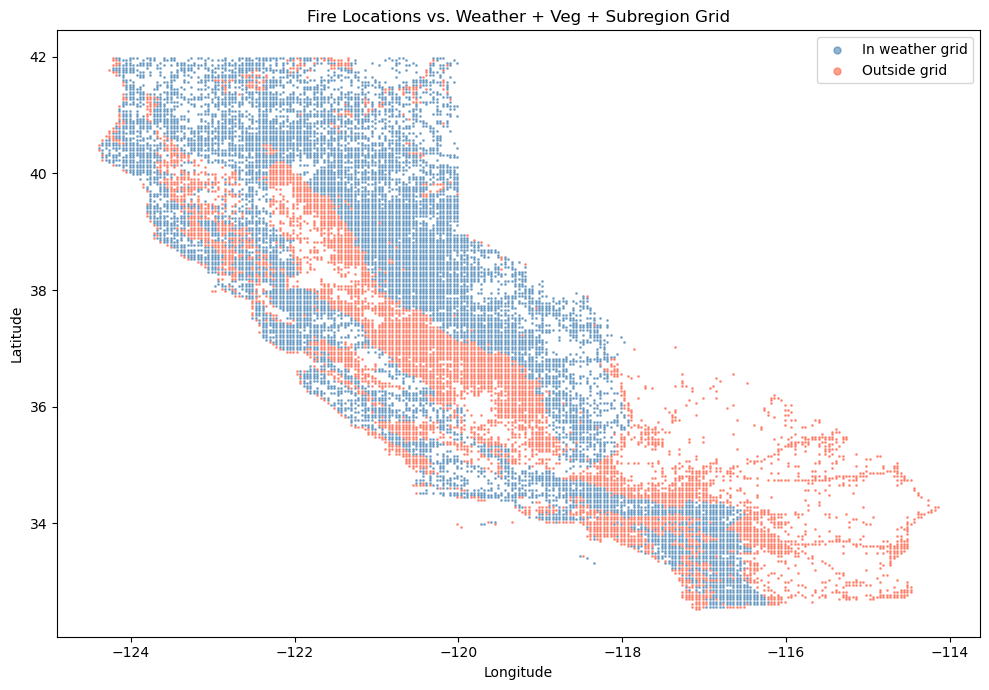

In [10]:
fire_locs = expanded.merge(
    weather, on=['lon','lat','day'], how='left', indicator='in_weather'
) if False else expanded[['lon','lat']].drop_duplicates().merge(
    lon_lat, on=['lon','lat'], how='left', indicator='in_weather'
)
fire_locs['in_weather'] = fire_locs['in_weather'] == 'both'
coverage = fire_locs['in_weather'].value_counts()
print("Fire location coverage in weather grid:")
print(coverage.to_string())

fig, ax = plt.subplots(figsize=(10,7))
for in_w, color, label in [(True,'steelblue','In weather grid'),(False,'tomato','Outside grid')]:
    sub = fire_locs[fire_locs['in_weather']==in_w]
    ax.scatter(sub['lon'], sub['lat'], s=1, c=color, alpha=0.6, label=label)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Fire Locations vs. Weather + Veg + Subregion Grid')
ax.legend(markerscale=5)
plt.tight_layout(); plt.show()

---

# Phase D: Merge onto Grid Skeleton & Finalize

Left-join fire labels onto the full monthly skeleton, keeping only discovery-month rows
(remove in-progress fire months), then add a `prev_fire` lag feature.

## 10. Merge Fire Labels onto Skeleton

In [11]:
print(f"Skeleton rows before merge : {skeleton.shape[0]:,}")
labeled = skeleton.merge(expanded, on=['lon','lat','year_month'], how='left')
print(f"Skeleton rows after merge  : {labeled.shape[0]:,}")

Skeleton rows before merge : 4,697,280
Skeleton rows after merge  : 4,697,280


## 11. Remove In-Progress Fire Months

Months where `IS_DISCOVERY_MONTH = False` (fire ongoing but not starting) are ambiguous
— the grid cell is on fire but we cannot use it as a non-fire observation. Drop them.

In [12]:
print(f"IS_DISCOVERY_MONTH distribution:\n{labeled['IS_DISCOVERY_MONTH'].value_counts(dropna=False).to_string()}")
print(f"\nBefore filter : {labeled.shape[0]:,}")
labeled = labeled[labeled['IS_DISCOVERY_MONTH'].isna() | labeled['IS_DISCOVERY_MONTH']]
print(f"After filter  : {labeled.shape[0]:,}")
print(f"Removed       : {skeleton.shape[0] - labeled.shape[0]:,} in-progress fire months")

IS_DISCOVERY_MONTH distribution:
IS_DISCOVERY_MONTH
NaN      4604261
True       79595
False      13424

Before filter : 4,697,280
After filter  : 4,683,856
Removed       : 13,424 in-progress fire months


## 12. Finalize Labels

In [13]:
# IS_FIRE: 1 = discovery month, 0 = non-fire month
labeled['IS_FIRE'] = labeled['IS_DISCOVERY_MONTH'].fillna(0).astype(int)
labeled = labeled.drop(columns=['IS_DISCOVERY_MONTH'])

# Fill fire size to 0 for non-fire rows
labeled['min_FIRE_SIZE'] = labeled['min_FIRE_SIZE'].fillna(0)
labeled['max_FIRE_SIZE'] = labeled['max_FIRE_SIZE'].fillna(0)

fire_rate = labeled['IS_FIRE'].mean() * 100
print(f"IS_FIRE distribution:\n{labeled['IS_FIRE'].value_counts().to_string()}")
print(f"\nFire rate : {fire_rate:.3f}%")
print(f"Date range: {labeled['year_month'].min().date()} → {labeled['year_month'].max().date()}")

IS_FIRE distribution:
IS_FIRE
0    4604261
1      79595

Fire rate : 1.699%
Date range: 1994-01-01 → 2023-12-01


## 13. Trim to Analysis Period & Add `prev_fire` Lag

In [14]:
# Trim to 1994–2020 (weather data end date)
print(f"Before date trim : {labeled.shape[0]:,}")
labeled = labeled[labeled['year_month'] <= '2020-12-31']
print(f"After date trim  : {labeled.shape[0]:,}")

# prev_fire: was the previous month a fire at the same grid cell?
labeled = labeled.sort_values(['lon','lat','year_month'])
labeled['prev_fire'] = (
    labeled.groupby(['lon','lat'])['IS_FIRE']
    .shift(1).fillna(0).astype(int)
)

print(f"\nFinal shape : {labeled.shape}")
labeled.head(5)

Before date trim : 4,683,856
After date trim  : 4,214,167

Final shape : (4214167, 7)


,lon,lat,year_month,min_FIRE_SIZE,max_FIRE_SIZE,IS_FIRE,prev_fire
0,-124.391667,40.441667,1994-01-01,0.0,0.0,0,0
1,-124.391667,40.441667,1994-02-01,0.0,0.0,0,0
2,-124.391667,40.441667,1994-03-01,0.0,0.0,0,0
3,-124.391667,40.441667,1994-04-01,0.0,0.0,0,0
4,-124.391667,40.441667,1994-05-01,0.0,0.0,0,0


## 14. Save Output

In [15]:
out_path = os.path.join(FIRE_OUTPUT_DIR, FIRE_OUTPUT_FILE)
labeled.to_parquet(out_path, index=False)

print(f"Saved -> {out_path}")
print(f"File size  : {os.path.getsize(out_path)/1e6:.1f} MB")
print(f"Final shape: {labeled.shape[0]:,} rows × {labeled.shape[1]} cols")
print(f"Columns    : {list(labeled.columns)}")

Saved -> E:\zcao\CA_Wildfire\Clean_Data\Fire_Data\Extended_Fire_Data\calfire_fod_fpa_1994_2020_fire_label_monthly.parquet
File size  : 1.5 MB
Final shape: 4,214,167 rows × 7 cols
Columns    : ['lon', 'lat', 'year_month', 'min_FIRE_SIZE', 'max_FIRE_SIZE', 'IS_FIRE', 'prev_fire']


## 15. Summary

| Phase | Step | Description | Key Result |
|-------|------|-------------|------------|
| A | Weather grid | Extract unique (lon, lat) pairs | ~13k grid cells |
| A | Skeleton | Cross-join grid × all months | ~4.7M (lon,lat,month) rows |
| B | Load fire | FPA-FOD deduplicated grid-snapped data | ~164k events |
| B | Daily dedup | Group by (lon,lat,discovery,containment) | Exact duplicates removed |
| B | Monthly dedup | Collapse to month-level | Each (lon,lat,month) unique |
| C | Expand | One row per month from discovery → containment | Mark discovery month |
| C | Dedup expanded | Group by (lon,lat,month) — keep any=True | Final fire events |
| C | Coverage QA | Map fire locations vs. weather grid | Boundary fires identified |
| D | Merge | Left join fire labels onto skeleton | Row count preserved |
| D | Filter | Remove in-progress fire months | ~14k months removed |
| D | Finalize | IS_FIRE binary, fill fire size, date trim | 1994–2020 |
| D | prev_fire | Lag feature: previous month fire at same cell | New column added |
| D | Save | `calfire_fod_fpa_1994_2020_fire_label_monthly.parquet` | Final output |